In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
from google.colab import files

# Step 1: Upload the file
uploaded = files.upload()

# Step 2: Read the dataset
df = pd.read_excel("logistic_regression_CaseStudy.xlsx")

# Display first 5 rows
print(df.head())

Saving logistic_regression_CaseStudy.xlsx to logistic_regression_CaseStudy.xlsx
   Employee_ID  Age  Gender  Department Education_Level  Years_of_Experience  \
0            1   59  Female   Marketing         Diploma                   34   
1            2   49  Female          IT          Master                   27   
2            3   35    Male  Operations             PhD                   15   
3            4   28  Female       Sales        Bachelor                    7   
4            5   41    Male          IT         Diploma                   17   

   Monthly_Salary  Work_Hours_Per_Week  Projects_Handled  \
0           53281                   33                13   
1           92275                   57                 1   
2           26525                   45                12   
3           41453                   68                 2   
4           31251                   54                10   

   Job_Satisfaction_Score  Promotion_Last_2_Years  Remote_Work  \
0           

In [ ]:
df.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
Department,0
Education_Level,0
Years_of_Experience,0
Monthly_Salary,0
Work_Hours_Per_Week,0
Projects_Handled,0
Job_Satisfaction_Score,0


In [ ]:
print(df.columns)

Index(['Employee_ID', 'Age', 'Gender', 'Department', 'Education_Level',
       'Years_of_Experience', 'Monthly_Salary', 'Work_Hours_Per_Week',
       'Projects_Handled', 'Job_Satisfaction_Score', 'Promotion_Last_2_Years',
       'Remote_Work', 'Training_Hours', 'Attrition_Flag'],
      dtype='object')


In [ ]:
print(df.shape)

(10000, 14)


In [ ]:
print(df.info)

<bound method DataFrame.info of       Employee_ID  Age  Gender  Department Education_Level  \
0               1   59  Female   Marketing         Diploma   
1               2   49  Female          IT          Master   
2               3   35    Male  Operations             PhD   
3               4   28  Female       Sales        Bachelor   
4               5   41    Male          IT         Diploma   
...           ...  ...     ...         ...             ...   
9995         9996   44  Female       Sales          Master   
9996         9997   33  Female  Operations         Diploma   
9997         9998   49  Female     Finance         Diploma   
9998         9999   52    Male  Operations        Bachelor   
9999        10000   44  Female   Marketing             PhD   

      Years_of_Experience  Monthly_Salary  Work_Hours_Per_Week  \
0                      34           53281                   33   
1                      27           92275                   57   
2                      15

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
categoruiacal_columns = df.select_dtypes(include=['object']).columns
print(categoruiacal_columns)

Index(['Gender', 'Department', 'Education_Level'], dtype='object')


In [ ]:
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['Department'] = le.fit_transform(df['Department'])
df['Education_Level'] = le.fit_transform(df['Education_Level'])


Objective:

The objective of this experiment is to implement
Support Vector Machine (SVM) algorithm on a
practice dataset to classify data into
predefined categories.

SVM finds the best hyperplane that separates
data into different classes with maximum margin.

In [ ]:
X = df.drop('Department', axis=1)
y = df['Department']

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
svm_model = SVC(
    kernel='rbf',
    C=1
)

In [ ]:
svm_model.fit(X_train, y_train)

SVC(C=1)

In [ ]:
y_pred = svm_model.predict(X_test)

print(y_pred)

[5 0 4 ... 1 1 0]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.1675


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 57 100  26  37  84  31]
 [ 57 103  29  58  60  40]
 [ 55  96  33  50  71  39]
 [ 56 102  28  52  58  41]
 [ 52 112  30  29  57  30]
 [ 62  85  34  52  61  33]]


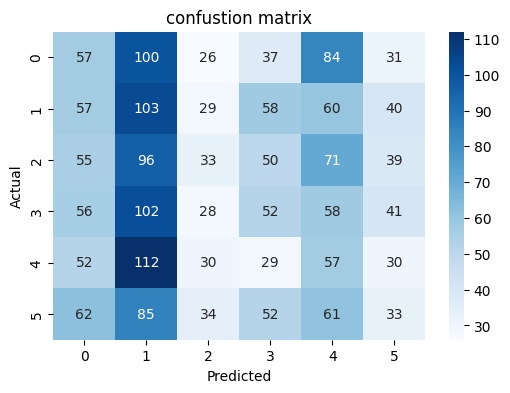

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("confustion matrix")
plt.show()

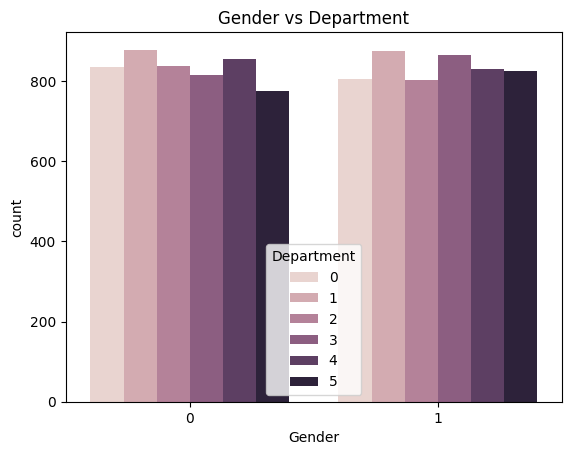

In [ ]:
sns.countplot(x='Gender',
              hue='Department',
              data=df)

plt.title("Gender vs Department")
plt.show()

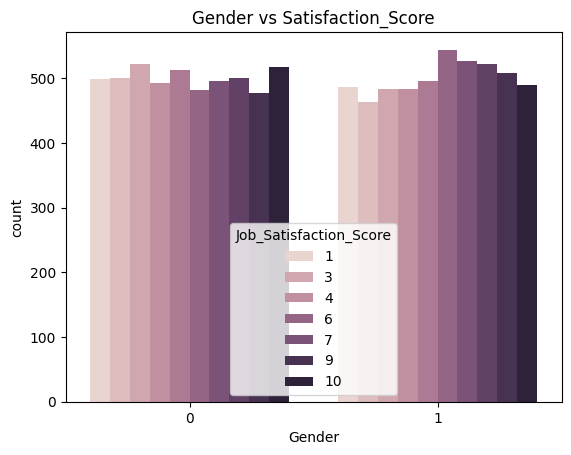

In [ ]:
sns.countplot(x='Gender',
              hue='Job_Satisfaction_Score',
              data=df)

plt.title("Gender vs Satisfaction_Score")
plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.17      0.17      0.17       335
           1       0.17      0.30      0.22       347
           2       0.18      0.10      0.13       344
           3       0.19      0.15      0.17       337
           4       0.15      0.18      0.16       310
           5       0.15      0.10      0.12       327

    accuracy                           0.17      2000
   macro avg       0.17      0.17      0.16      2000
weighted avg       0.17      0.17      0.16      2000



In [ ]:
svm_rbf = SVC(kernel='rbf', C=1)

svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)

print(" RBF Accuracy:",accuracy_score(y_test, y_pred_rbf))

 RBF Accuracy: 0.1675


In [ ]:
svm_poly = SVC(
    kernel='poly',
    degree=3,
)

svm_poly.fit(X_train, y_train)

y_pred = svm_poly.predict(X_test)

print("polynomial Accuracy:",accuracy_score(y_test, y_pred_rbf))

polynomial Accuracy: 0.1675


In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf','linear']
}

In [ ]:
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=2 )

In [ ]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   4.4s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   4.4s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   5.6s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   4.7s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   7.4s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   3.4s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   3.1s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   3.1s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   4.3s
[CV] END ......................C=0.1, gamma=1, kernel=linear; total time=   3.1s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   4.6s
[CV] END .......................C=0.1, gamma=0.

In [ ]:
print(grid.best_params_)

In [ ]:
print(grid.best_estimator_)

In [ ]:
best_model = grid.best_estimator_

final_predictions = best_model.predict(X_test)
print("Final Accuracy:", accuracy_score(y_test, final_predictions))

Conclusion:

In this experiment, Support Vector Machine (SVM)
algorithm was implemented on a practice dataset.

SVM is a supervised machine learning algorithm
that classifies data by finding the optimal
hyperplane between classes.

It works well for both linear and non-linear
classification problems using kernel functions.

The model was trained on 80% data and
tested on 20% data.

Thus, SVM successfully classified the data
with good accuracy.